# ## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from google.colab import files

# ## 2. Upload and Load Dataset


In [2]:
print("Please upload your dataset CSV file.")
uploaded = files.upload()
dataset_path = next(iter(uploaded))
df = pd.read_csv(dataset_path)

print("\nInitial Data Shape:", df.shape)

Please upload your dataset CSV file.


Saving Student Depression Dataset.csv to Student Depression Dataset.csv

Initial Data Shape: (27901, 18)


# ## 3. Data Cleaning


In [3]:

def clean_data(df):
    df = df.copy()
    df.drop_duplicates(inplace=True)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    categorical_cols = df.select_dtypes(include='object').columns
    for col in categorical_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    return df




# Execute Cleaning



In [4]:
df = clean_data(df)
print("Data cleaning completed.")

Data cleaning completed.


<ipython-input-3-374a80ab0148>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


# ## 4. Outlier Detection and Handling




In [5]:
def detect_outliers_zscore(df, threshold=3):
    outlier_indices = []
    for col in df.select_dtypes(include=[np.number]).columns:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers = np.where(z_scores > threshold)
        outlier_indices.extend(outliers[0])
    return list(set(outlier_indices))

# Detect and Handle Outliers

In [6]:
outliers = detect_outliers_zscore(df)
print(f"Number of outliers detected: {len(outliers)}")

def handle_outliers(df):
    df = df.copy()
    for col in df.select_dtypes(include=[np.number]).columns:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = np.clip(df[col], lower, upper)
    return df


Number of outliers detected: 30


# Execute Outlier Handling


In [7]:
df = handle_outliers(df)
print("Outlier handling completed.")

Outlier handling completed.


# ## 5. Feature Engineering

In [8]:
def feature_engineering(df):
    df = df.copy()
    if 'age' in df.columns:
        df['age_group'] = pd.cut(df['age'], bins=[0, 18, 22, 30, 100], labels=['Teen', 'Young Adult', 'Adult', 'Older'])
    if {'anxiety', 'stress'}.issubset(df.columns):
        df['mental_health_risk'] = df['anxiety'] + df['stress']
    return df

# Execute Feature Engineering


In [9]:
df = feature_engineering(df)
print("Feature engineering completed.")


Feature engineering completed.


# ## 6. Encode Categorical Variables


In [10]:
def encode_categoricals(df):
    df = df.copy()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        df[col] = df[col].astype('category').cat.codes
        df[col] = df[col].astype('int64')
    return df

# Execute Encoding

In [11]:
print("Before encoding:", df.dtypes)
df = encode_categoricals(df)
print("Encoding completed.")
print("After encoding:", df.dtypes)

Before encoding: id                                          int64
gender                                     object
age                                       float64
city                                       object
profession                                 object
academic_pressure                         float64
work_pressure                             float64
cgpa                                      float64
study_satisfaction                        float64
job_satisfaction                          float64
sleep_duration                             object
dietary_habits                             object
degree                                     object
have_you_ever_had_suicidal_thoughts_?      object
work/study_hours                          float64
financial_stress                          float64
family_history_of_mental_illness           object
depression                                  int64
age_group                                category
dtype: object
Encoding completed.

# ## 7. Train-Test Split


In [12]:
def split_data(df, target_col):
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    return train_test_split(X, y, test_size=0.2, random_state=42)


# Define Target and Split


In [13]:
target_column = 'depression'  # Update if needed
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found in dataset columns: {df.columns.tolist()}")

X_train, X_test, y_train, y_test = split_data(df, target_column)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (22320, 18), Test shape: (5581, 18)


# ## 8. Correlation Analysis


In [14]:
def correlation_analysis(df):
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()
    plt.figure(figsize=(15, 12))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
    plt.title('Correlation Matrix Heatmap')
    plt.show()

# Execute Correlation Analysis


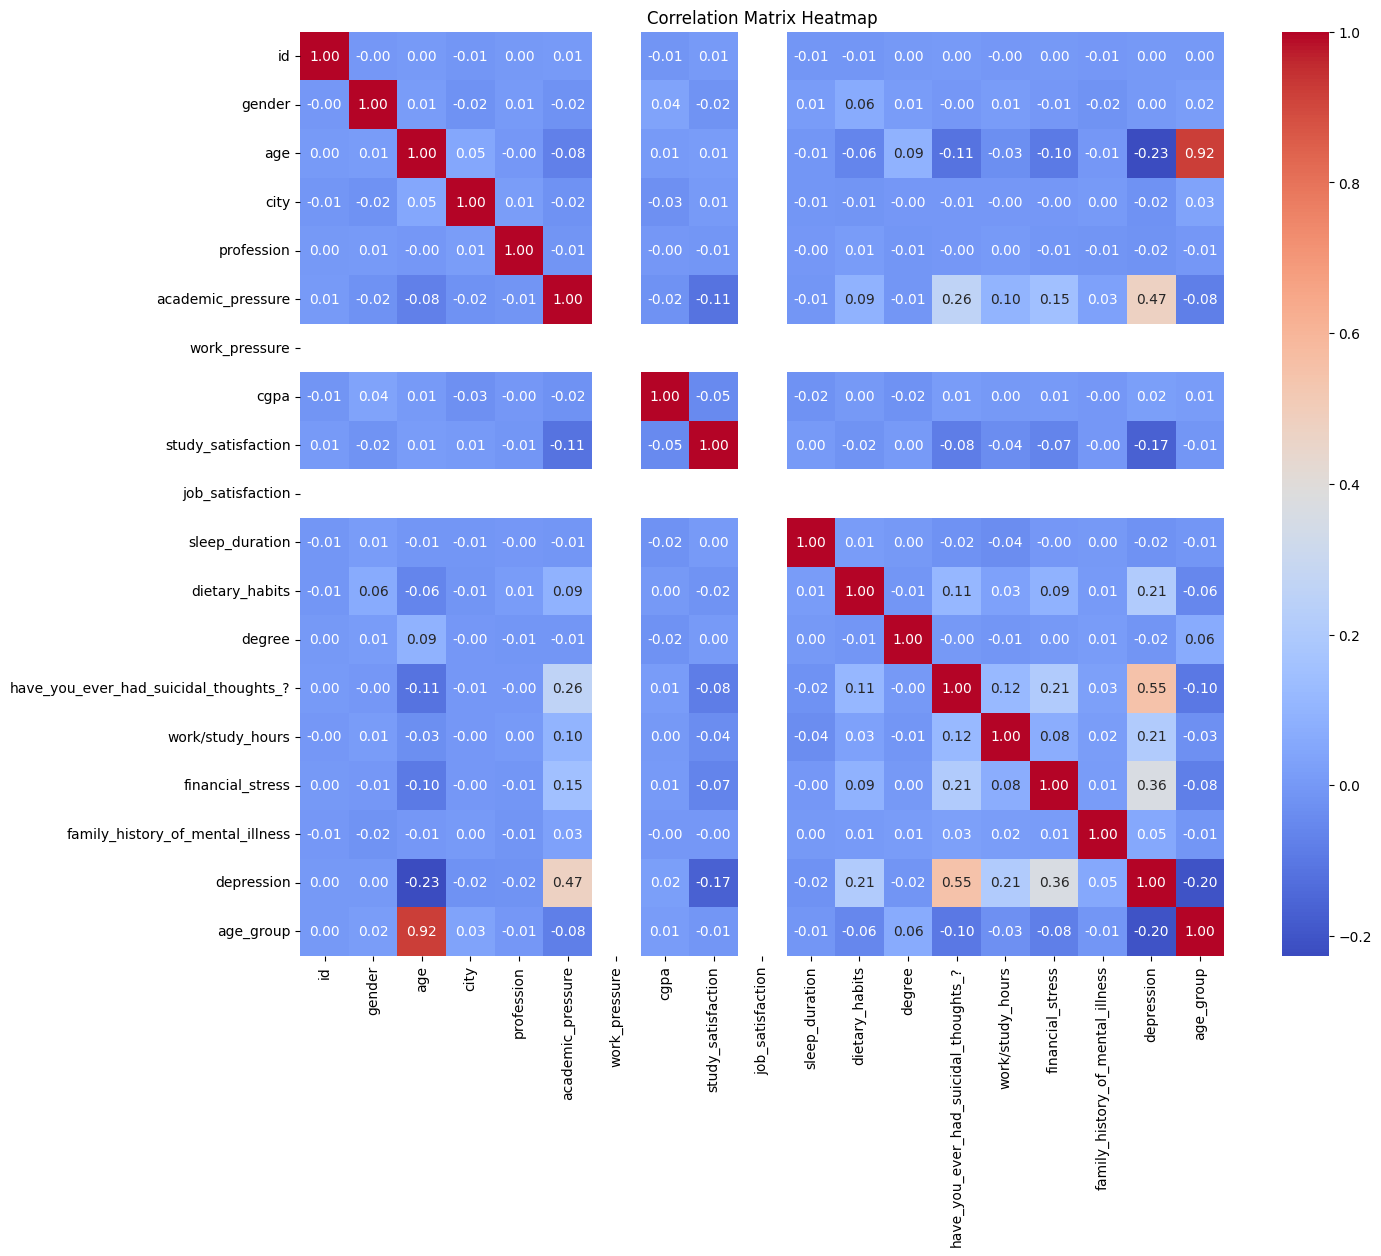

In [15]:
correlation_analysis(df)


# ## 9. Clustering Analysis (KMeans + PCA Visualization)


# PCA

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)


# KMeans Clustering

In [17]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_pca)
clusters = kmeans.labels_

# Plot Clusters

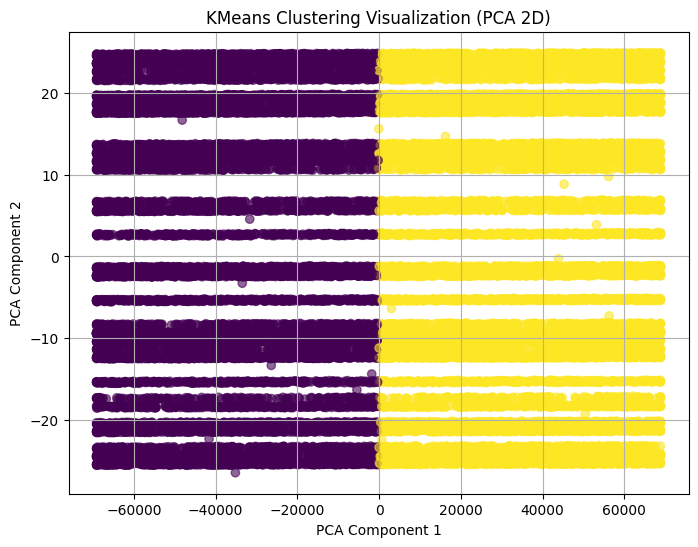

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('KMeans Clustering Visualization (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

# Elbow Method to Determine Optimal k

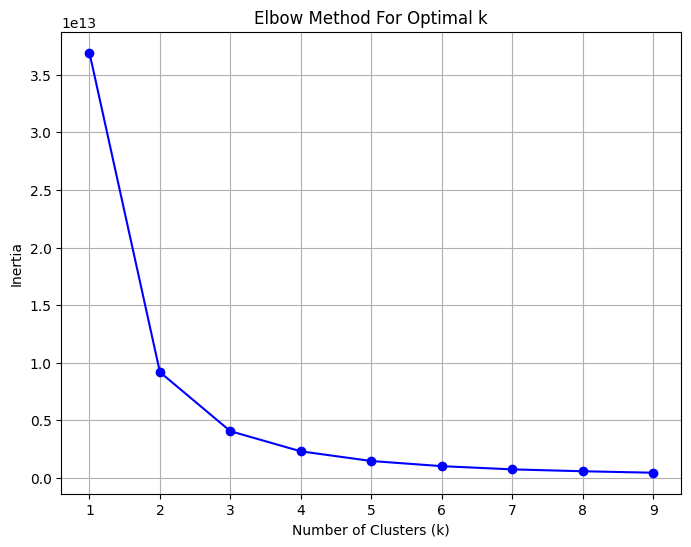

Clustering analysis completed! ✅


In [19]:
inertia = []
k_values = range(1, 10)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(k_values, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

print("Clustering analysis completed! ✅")

# ## 10. Baseline Model: Dummy Classifier

In [20]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

print("\nBaseline Dummy Classifier Performance:")
print(classification_report(y_test, y_pred_dummy))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))



Baseline Dummy Classifier Performance:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2343
           1       0.58      1.00      0.73      3238

    accuracy                           0.58      5581
   macro avg       0.29      0.50      0.37      5581
weighted avg       0.34      0.58      0.43      5581

Confusion Matrix:
 [[   0 2343]
 [   0 3238]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# ## 11. Classification Models Training and Evaluation


In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}


# Utility function to evaluate models


In [22]:
def evaluate_model(name, y_true, y_pred, results_list):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# Train and evaluate all models

In [23]:
results = []
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    evaluate_model(name, y_test, y_pred, results)



Training Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2343
           1       0.85      0.87      0.86      3238

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581


Training Random Forest...
              precision    recall  f1-score   support

           0       0.81      0.78      0.79      2343
           1       0.84      0.87      0.85      3238

    accuracy                           0.83      5581
   macro avg       0.82      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581


Training Decision Tree...
              precision    recall  f1-score   support

           0       0.69      0.72      0.70      2343
           1       0.79      0.77      0.78      3238

    accuracy                           0.75      5581
   macro avg       0.74      0.74      0.74      5581
weighted avg       0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Evaluate Dummy Classifier separately


In [24]:
evaluate_model('Dummy Classifier', y_test, y_pred_dummy, results)


# ## 12. Final Model Evaluation Comparison


In [25]:

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False)

print("\nModel Evaluation Metrics Comparison:")
print(results_df)



Model Evaluation Metrics Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.835513   0.851302  0.868128  0.859633
1        Random Forest  0.827988   0.842453  0.865349  0.853748
2        Decision Tree  0.746820   0.789407  0.768684  0.778908
3                  SVM  0.580183   0.580183  1.000000  0.734324
4     Dummy Classifier  0.580183   0.580183  1.000000  0.734324
